Please upload the QUANTITATIVE dataset (e.g., quant_data.xlsx).


Saving candidate_responses_1200_validated.xlsx to candidate_responses_1200_validated (3).xlsx
First few rows of the quantitative dataset:
   Profile ID                      Department       Location Internship  \
0           1      Data and Decision Sciences             US        Yes   
1           2      Data and Decision Sciences             US         No   
2           3      Data and Decision Sciences  International        Yes   
3           4      Data and Decision Sciences  International         No   
4           5  Quantitative and Data Sciences             US        Yes   

                                              Prompt  Response  
0  Given this summary of the candidate's backgrou...        80  
1  Given this summary of the candidate's backgrou...        50  
2  Given this summary of the candidate's backgrou...        80  
3  Given this summary of the candidate's backgrou...        60  
4  Given this summary of the candidate's backgrou...        80  


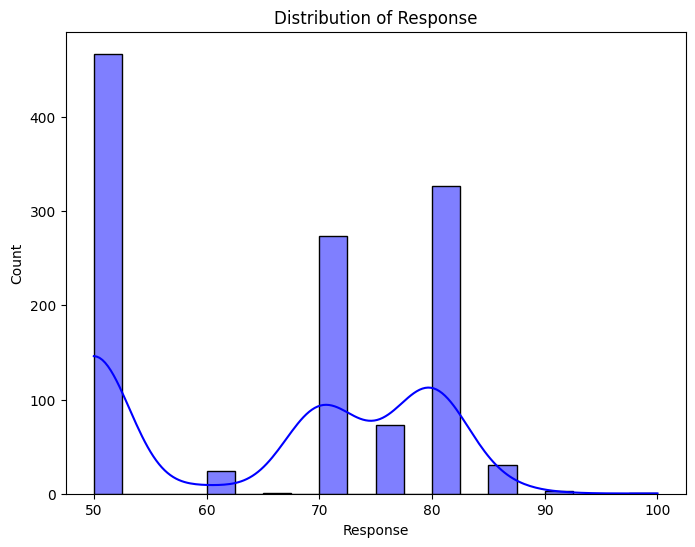

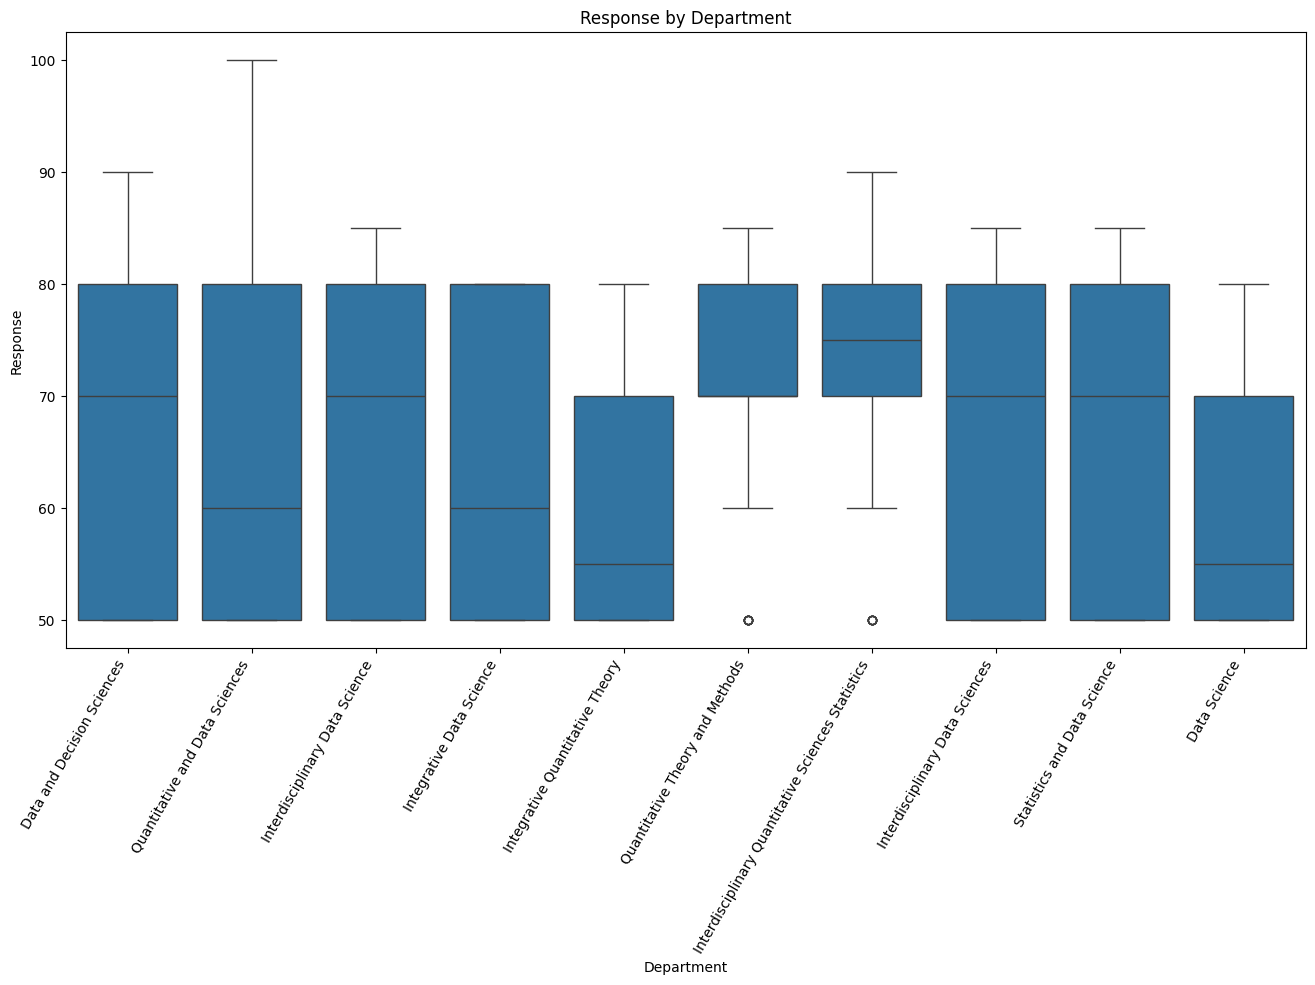

Mean Ratings by Location:
 Location
International    65.300000
US               65.683333
Name: Response, dtype: float64

Mean Ratings by Internship:
 Internship
No     54.216667
Yes    76.766667
Name: Response, dtype: float64


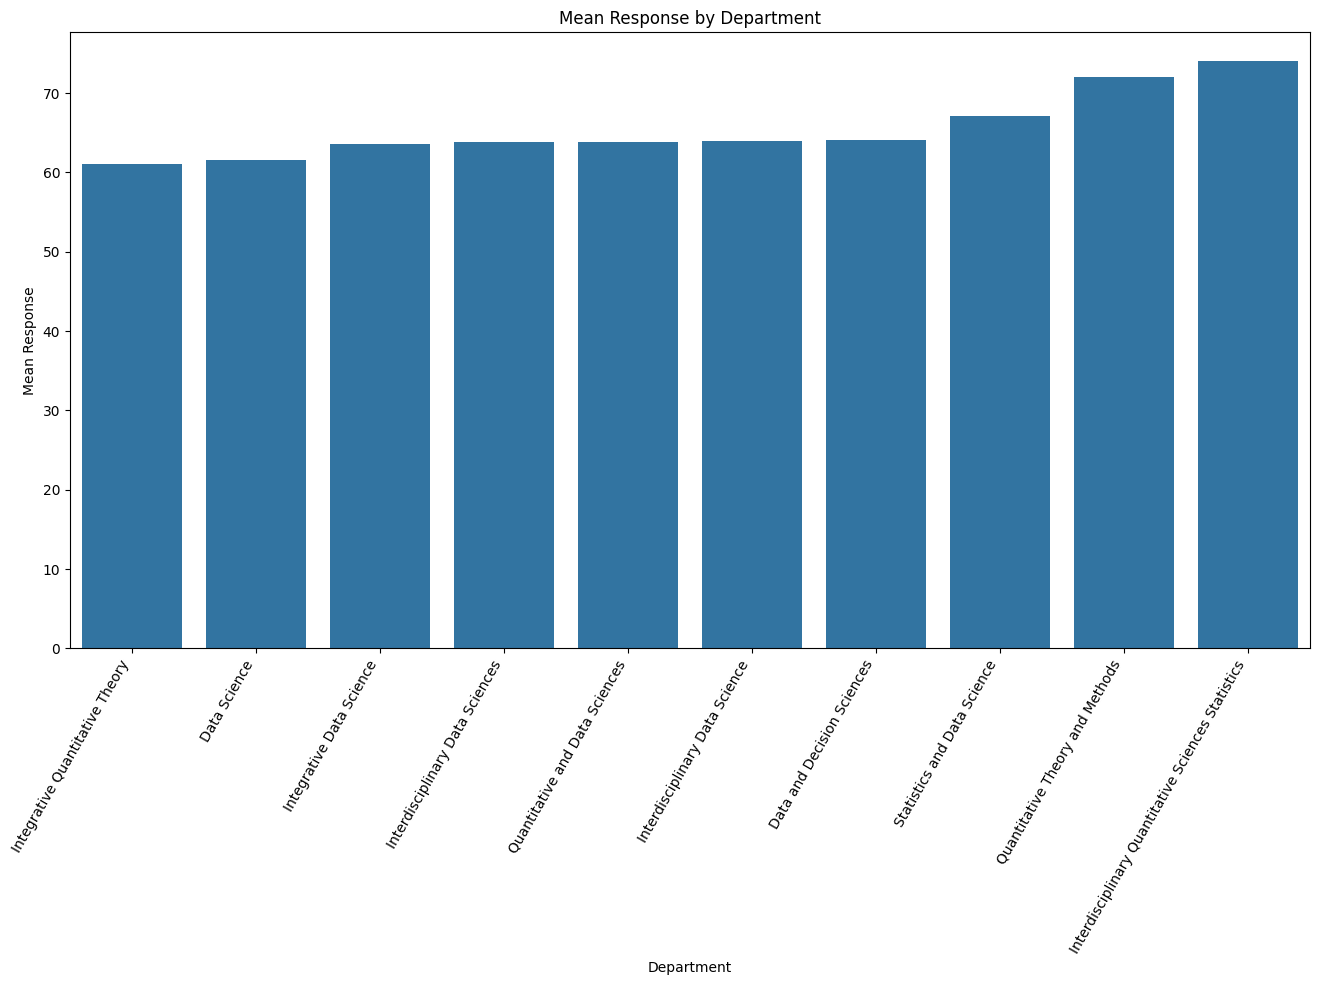


OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:               Response   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     525.1
Date:                Tue, 10 Dec 2024   Prob (F-statistic):               0.00
Time:                        04:07:09   Log-Likelihood:                -3735.3
No. Observations:                1200   AIC:                             7495.
Df Residuals:                    1188   BIC:                             7556.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [ ]:
# Import necessary libraries
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
import textwrap

# Upload the quantitative dataset
print("Please upload the QUANTITATIVE dataset (e.g., quant_data.xlsx).")
uploaded_quant = files.upload()

# Extract filename of the uploaded quantitative dataset
quant_file = list(uploaded_quant.keys())[0]

# Read the Excel file into a DataFrame
df_quant = pd.read_excel(quant_file)

# Quick check: Display the first few rows of the quantitative dataset
print("First few rows of the quantitative dataset:")
print(df_quant.head())

# --- Data Cleaning ---
# Ensure no invalid ratings (Response between 0 and 100)
df_quant = df_quant[df_quant['Response'].between(0, 100)]

# Drop duplicates based on 'Profile ID'
df_quant = df_quant.drop_duplicates(subset='Profile ID')

# --- Exploratory Data Analysis (EDA) ---
# 1. Distribution of Ratings
plt.figure(figsize=(8, 6))
sns.histplot(df_quant['Response'], bins=20, kde=True, color='blue')
plt.title('Distribution of Response')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

# 2. Boxplot by Department (Fixing alignment for long department names)
plt.figure(figsize=(16, 8))  # Adjust figure size
sns.boxplot(x='Department', y='Response', data=df_quant)
plt.xticks(rotation=60, ha='right')  # Rotate and align labels for readability
plt.title('Response by Department')
plt.xlabel('Department')
plt.ylabel('Response')
plt.show()

# 3. Mean Ratings by Location and Internship
mean_ratings_by_location = df_quant.groupby('Location')['Response'].mean()
mean_ratings_by_internship = df_quant.groupby('Internship')['Response'].mean()

print("Mean Ratings by Location:\n", mean_ratings_by_location)
print("\nMean Ratings by Internship:\n", mean_ratings_by_internship)

# 4. Barplot for Mean Ratings by Department
dept_mean = df_quant.groupby('Department')['Response'].mean().sort_values()
plt.figure(figsize=(16, 8))  # Adjust figure size for clarity
sns.barplot(x=dept_mean.index, y=dept_mean.values)
plt.xticks(rotation=60, ha='right')  # Rotate and align labels for readability
plt.title('Mean Response by Department')
plt.xlabel('Department')
plt.ylabel('Mean Response')
plt.show()

# --- Regression Modeling ---
# 1. OLS Regression to study the effect of Department, Location, Internship
model = smf.ols("Response ~ C(Department) + C(Location) + C(Internship)", data=df_quant).fit()
print("\nOLS Regression Summary:")
print(model.summary())

# 2. Optional: Interaction Effects (Department, Location, Internship)
model_interact = smf.ols("Response ~ C(Department)*C(Location)*C(Internship)", data=df_quant).fit()
print("\nOLS Regression Summary with Interactions:")
print(model_interact.summary())


Please upload the dataset (e.g., candidate_qualitative_responses_1200.xlsx).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving candidate_qualitative_responses_1200.xlsx to candidate_qualitative_responses_1200 (3).xlsx
First few rows of the dataset:
   Profile ID                      Department       Location Internship  \
0           1      Data and Decision Sciences             US        Yes   
1           2      Data and Decision Sciences             US         No   
2           3      Data and Decision Sciences  International        Yes   
3           4      Data and Decision Sciences  International         No   
4           5  Quantitative and Data Sciences             US        Yes   

                                              Prompt  \
0  Given this summary of the candidate's backgrou...   
1  Given this summary of the candidate's backgrou...   
2  Given this summary of the candidate's backgrou...   
3  Given this summary of the candidate's backgrou...   
4  Given this summary of the candidate's backgrou...   

                                            Response  
0  Evaluation:\n\nProfile ID

<ipython-input-8-c2a45672cc71>:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mentions', y='Department', data=dept_counts_df, palette='viridis')


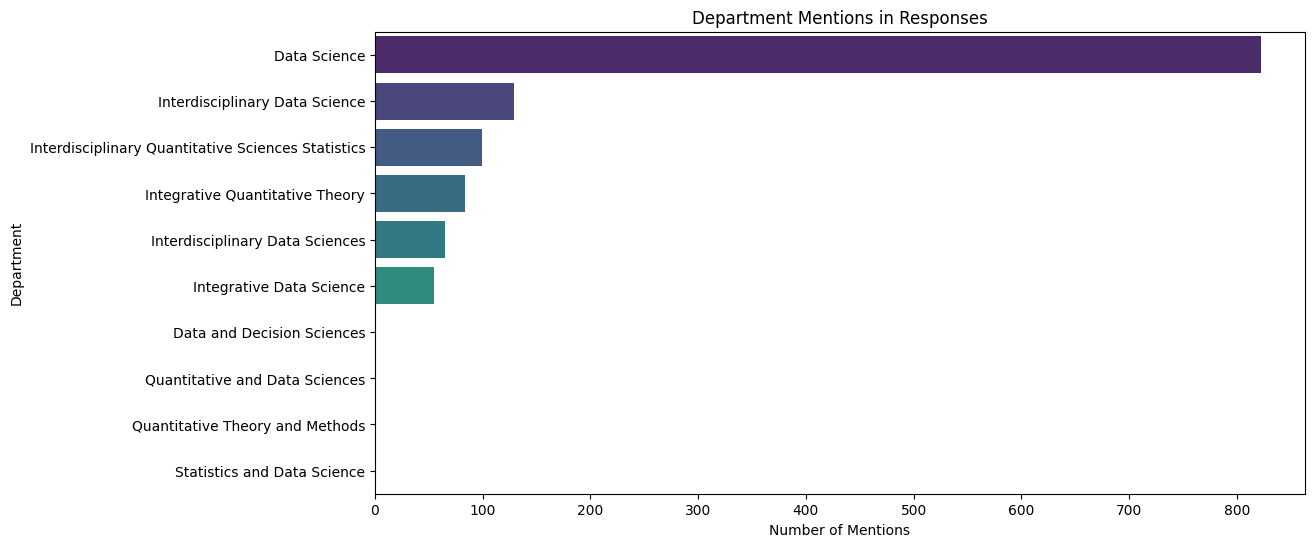

<ipython-input-8-c2a45672cc71>:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Sentiment', y='Department', data=dept_counts_df, palette='coolwarm')


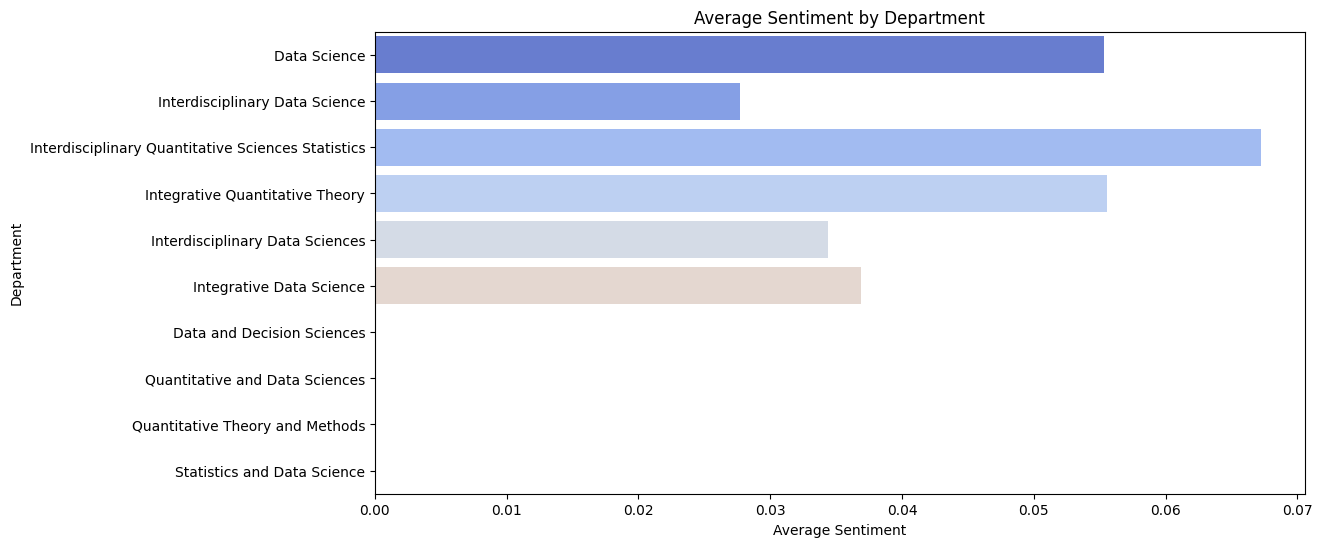

Department Mentions and Sentiment Analysis:
                                          Department  Mentions  \
9                                       Data Science       822   
2                     Interdisciplinary Data Science       129   
6  Interdisciplinary Quantitative Sciences Statis...        99   
4                    Integrative Quantitative Theory        84   
7                    Interdisciplinary Data Sciences        65   
3                           Integrative Data Science        55   
0                         Data and Decision Sciences         0   
1                     Quantitative and Data Sciences         0   
5                    Quantitative Theory and Methods         0   
8                        Statistics and Data Science         0   

   Average_Sentiment  
9           0.055361  
2           0.027703  
6           0.067216  
4           0.055531  
7           0.034387  
3           0.036857  
0                NaN  
1                NaN  
5                NaN  

In [ ]:
# Import necessary libraries
from google.colab import files
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Upload the dataset
print("Please upload the dataset (e.g., candidate_qualitative_responses_1200.xlsx).")
uploaded_file = files.upload()

# Extract filename
file_name = list(uploaded_file.keys())[0]

# Read the dataset
df = pd.read_excel(file_name)

# Quick check of the dataset
print("First few rows of the dataset:")
print(df.head())

# --- Data Cleaning ---
# Handle missing or insufficient information in the Response column
df['Response'] = df['Response'].fillna('')

# Define a text cleaning function
def clean_text(text):
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

# Clean the Response column
df['Cleaned_Response'] = df['Response'].apply(clean_text)

# --- Extract Department Names ---
# Extract department names directly from the dataset (assuming a column 'Department' exists)
department_names = df['Department'].unique()

# Count mentions of each department in the cleaned responses
department_counts = {dept: sum(df['Cleaned_Response'].str.contains(dept.lower())) for dept in department_names}

# Create a DataFrame for department mention counts
dept_counts_df = pd.DataFrame(department_counts.items(), columns=['Department', 'Mentions']).sort_values(by='Mentions', ascending=False)

# --- Sentiment Analysis for Each Department ---
# Function to calculate average sentiment for department mentions
def calculate_sentiment(dept, responses):
    dept_responses = responses[responses['Cleaned_Response'].str.contains(dept.lower())]
    return dept_responses['Cleaned_Response'].apply(lambda x: TextBlob(x).sentiment.polarity).mean()

# Calculate sentiment for each department
dept_sentiments = {dept: calculate_sentiment(dept, df) for dept in department_names}

# Add sentiment to the department DataFrame
dept_counts_df['Average_Sentiment'] = dept_counts_df['Department'].apply(lambda dept: dept_sentiments[dept])

# --- Visualization ---
# Plot department mentions
plt.figure(figsize=(12, 6))
sns.barplot(x='Mentions', y='Department', data=dept_counts_df, palette='viridis')
plt.title('Department Mentions in Responses')
plt.xlabel('Number of Mentions')
plt.ylabel('Department')
plt.show()

# Plot average sentiment for departments
plt.figure(figsize=(12, 6))
sns.barplot(x='Average_Sentiment', y='Department', data=dept_counts_df, palette='coolwarm')
plt.title('Average Sentiment by Department')
plt.xlabel('Average Sentiment')
plt.ylabel('Department')
plt.show()

# --- Insights ---
print("Department Mentions and Sentiment Analysis:")
print(dept_counts_df)

# Highlight the most mentioned and positively associated departments
most_mentioned = dept_counts_df.loc[dept_counts_df['Mentions'].idxmax()]
most_positive = dept_counts_df.loc[dept_counts_df['Average_Sentiment'].idxmax()]

print(f"\nMost Mentioned Department: {most_mentioned['Department']} with {most_mentioned['Mentions']} mentions.")
print(f"Most Positively Associated Department: {most_positive['Department']} with an average sentiment of {most_positive['Average_Sentiment']:.2f}.")

Please upload the dataset (e.g., candidate_qualitative_responses_1200.xlsx).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving candidate_qualitative_responses_1200.xlsx to candidate_qualitative_responses_1200 (4).xlsx
First few rows of the dataset:
   Profile ID                      Department       Location Internship  \
0           1      Data and Decision Sciences             US        Yes   
1           2      Data and Decision Sciences             US         No   
2           3      Data and Decision Sciences  International        Yes   
3           4      Data and Decision Sciences  International         No   
4           5  Quantitative and Data Sciences             US        Yes   

                                              Prompt  \
0  Given this summary of the candidate's backgrou...   
1  Given this summary of the candidate's backgrou...   
2  Given this summary of the candidate's backgrou...   
3  Given this summary of the candidate's backgrou...   
4  Given this summary of the candidate's backgrou...   

                                            Response  
0  Evaluation:\n\nProfile ID

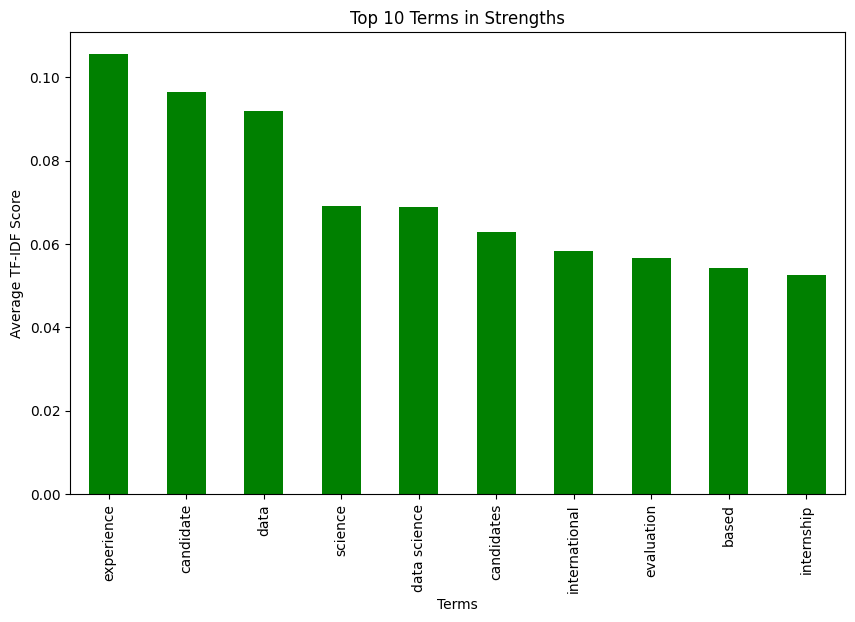

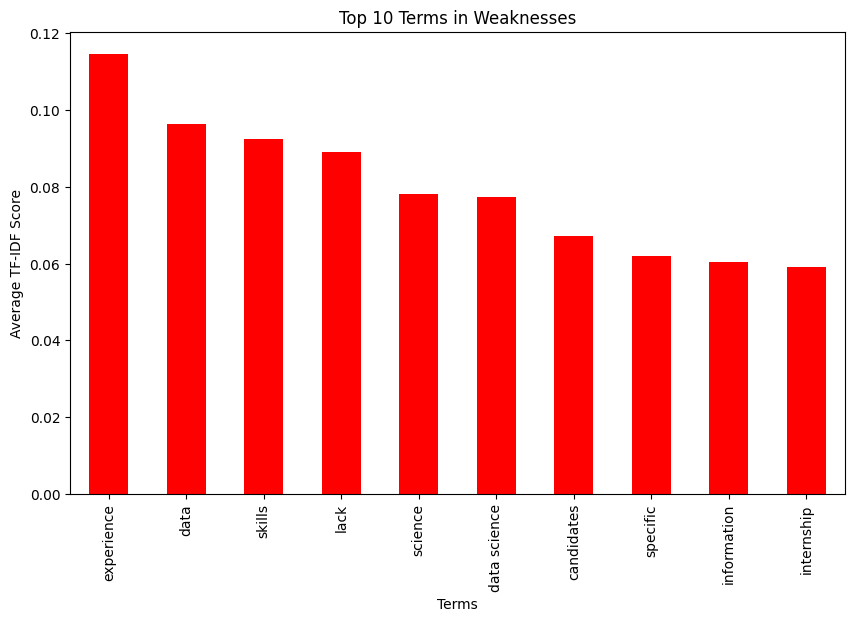

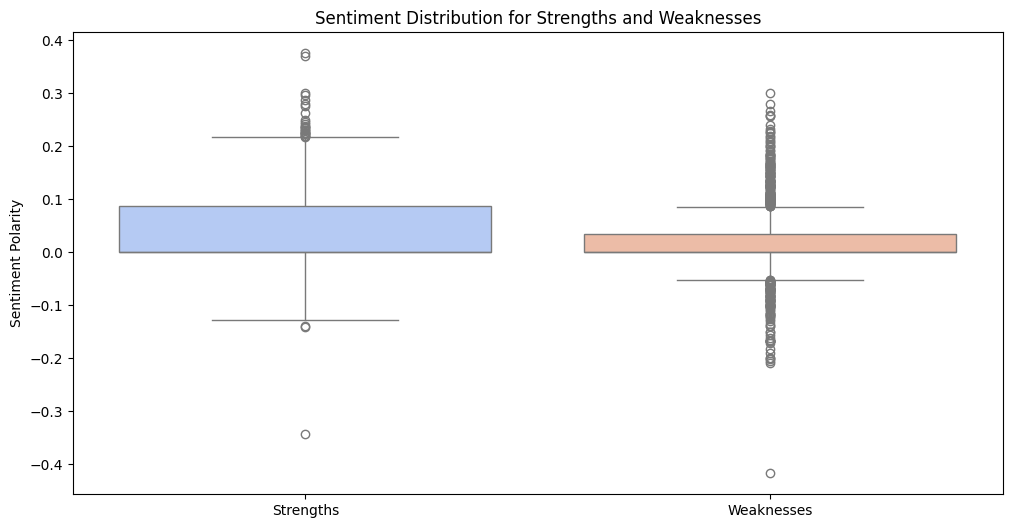


Top 10 Words in Strengths by TF-IDF:
experience       0.105521
candidate        0.096368
data             0.091758
science          0.069029
data science     0.068969
candidates       0.062776
international    0.058209
evaluation       0.056636
based            0.054120
internship       0.052523
dtype: float64

Top 10 Words in Weaknesses by TF-IDF:
experience      0.114694
data            0.096368
skills          0.092362
lack            0.089032
science         0.078047
data science    0.077285
candidates      0.067181
specific        0.061914
information     0.060440
internship      0.059059
dtype: float64

Average Sentiment for Strengths: 0.04380519995136926
Average Sentiment for Weaknesses: 0.014628787690183796


In [ ]:
# Import necessary libraries
from google.colab import files
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Upload the dataset
print("Please upload the dataset (e.g., candidate_qualitative_responses_1200.xlsx).")
uploaded_file = files.upload()

# Extract filename
file_name = list(uploaded_file.keys())[0]

# Read the dataset
df = pd.read_excel(file_name)

# Quick check of the dataset
print("First few rows of the dataset:")
print(df.head())

# --- Data Cleaning ---
# Handle missing or insufficient information in the Response column
df['Response'] = df['Response'].fillna('')

# Define a text cleaning function
def clean_text(text):
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

# Clean the Response column
df['Cleaned_Response'] = df['Response'].apply(clean_text)

# --- Strengths and Weaknesses Analysis ---
# Separate strengths and weaknesses using simple keyword-based separation
# Assuming "Strengths" and "Weaknesses" are described in the `Response` column
df['Strengths'] = df['Response'].apply(lambda x: x.split("2. Weaknesses:")[0].replace("1. Strengths:", "").strip() if "2. Weaknesses:" in x else "")
df['Weaknesses'] = df['Response'].apply(lambda x: x.split("2. Weaknesses:")[1].strip() if "2. Weaknesses:" in x else "")

# Clean Strengths and Weaknesses columns
df['Cleaned_Strengths'] = df['Strengths'].apply(clean_text)
df['Cleaned_Weaknesses'] = df['Weaknesses'].apply(clean_text)

# --- Textual Analysis ---
# TF-IDF for Strengths and Weaknesses
vectorizer_strengths = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X_strengths = vectorizer_strengths.fit_transform(df['Cleaned_Strengths'])
strengths_feature_names = vectorizer_strengths.get_feature_names_out()

vectorizer_weaknesses = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X_weaknesses = vectorizer_weaknesses.fit_transform(df['Cleaned_Weaknesses'])
weaknesses_feature_names = vectorizer_weaknesses.get_feature_names_out()

# Convert TF-IDF matrices to DataFrames
tfidf_strengths_df = pd.DataFrame(X_strengths.toarray(), columns=strengths_feature_names)
tfidf_weaknesses_df = pd.DataFrame(X_weaknesses.toarray(), columns=weaknesses_feature_names)

# Calculate mean TF-IDF scores
mean_tfidf_strengths = tfidf_strengths_df.mean().sort_values(ascending=False)
mean_tfidf_weaknesses = tfidf_weaknesses_df.mean().sort_values(ascending=False)

# --- Sentiment Analysis for Strengths and Weaknesses ---
df['Strengths_Sentiment'] = df['Cleaned_Strengths'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['Weaknesses_Sentiment'] = df['Cleaned_Weaknesses'].apply(lambda x: TextBlob(x).sentiment.polarity)

# --- Visualization ---
# Top 10 Strengths and Weaknesses by TF-IDF
plt.figure(figsize=(10, 6))
mean_tfidf_strengths.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Terms in Strengths')
plt.xlabel('Terms')
plt.ylabel('Average TF-IDF Score')
plt.show()

plt.figure(figsize=(10, 6))
mean_tfidf_weaknesses.head(10).plot(kind='bar', color='red')
plt.title('Top 10 Terms in Weaknesses')
plt.xlabel('Terms')
plt.ylabel('Average TF-IDF Score')
plt.show()

# Sentiment Analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['Strengths_Sentiment', 'Weaknesses_Sentiment']], palette='coolwarm')
plt.title('Sentiment Distribution for Strengths and Weaknesses')
plt.xticks([0, 1], ['Strengths', 'Weaknesses'])
plt.ylabel('Sentiment Polarity')
plt.show()

# --- Insights ---
print("\nTop 10 Words in Strengths by TF-IDF:")
print(mean_tfidf_strengths.head(10))

print("\nTop 10 Words in Weaknesses by TF-IDF:")
print(mean_tfidf_weaknesses.head(10))

print("\nAverage Sentiment for Strengths:", df['Strengths_Sentiment'].mean())
print("Average Sentiment for Weaknesses:", df['Weaknesses_Sentiment'].mean())
